# 04_analysis - Analisi Errori e Label Noise

Analisi diagnostica per identificare le cause delle basse performance del modello.

**Sezioni**:
1. Caricamento modello 04d e inferenza su tutti i set
2. Analisi predizioni confident ma errate (candidati label noise)
3. Analisi errori per source dataset (APTOS vs EyePACS)
4. Matrice di confusione dettagliata e pattern di errore
5. Test APTOS-only vs Merged
6. Stima label noise con confident learning
7. Conclusioni e raccomandazioni

## 1. Setup e Caricamento Modello

In [2]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import json

import pandas as pd
import numpy as np
import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast

import timm
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.9.1+cu130
CUDA: True


In [3]:
def get_project_root():
    """Rileva la root del progetto."""
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        return notebook_dir.parent
    current = notebook_dir
    for _ in range(5):
        if (current / 'Data').exists():
            return current
        current = current.parent
    if sys.platform == 'linux' and Path('/mnt/c').exists():
        return Path('/mnt/c/Repository/multi-method-xai-diabetic-retinopathy')
    return Path('C:/Repository/multi-method-xai-diabetic-retinopathy')


PROJECT_ROOT = get_project_root()

# Carica config
with open(PROJECT_ROOT / 'config.yaml', 'r') as f:
    config = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / config['paths']['processed_dir']
RESULTS_DIR = PROJECT_ROOT / config['paths']['results_dir']
CHECKPOINTS_DIR = PROJECT_ROOT / config['paths']['checkpoints_dir']
ANALYSIS_DIR = RESULTS_DIR / 'error_analysis'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

SEED = config['seed']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_CONFIG = config['model']
CLASS_NAMES = MODEL_CONFIG['class_names']
NUM_CLASSES = MODEL_CONFIG['num_classes']

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")

Project root: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy
Device: cuda


In [4]:
# Carica dataset
aptos_df = pd.read_csv(PROCESSED_DIR / 'aptos_preprocessed.csv')
eyepacs_df = pd.read_csv(PROCESSED_DIR / 'eyepacs_preprocessed.csv')
messidor_df = pd.read_csv(PROCESSED_DIR / 'messidor2_preprocessed.csv')

# Merge e split identico a 04d
merged_df = pd.concat([aptos_df, eyepacs_df], ignore_index=True)
train_df, val_df = train_test_split(
    merged_df, test_size=0.15, stratify=merged_df['diagnosis'], random_state=SEED
)
test_df = messidor_df.copy()

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"\nSource nel train:")
print(train_df['source'].value_counts())

Train: 32,243  Val: 5,690  Test: 1,744

Source nel train:
source
EyePACS    29428
APTOS       2815
Name: count, dtype: int64


In [5]:
# Dataset e transforms (solo validazione, no augmentation)
val_transforms = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])


class DRDataset(Dataset):
    """Dataset per inferenza con tracking degli indici."""
    def __init__(self, dataframe, transform=None, project_root=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.project_root = project_root

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['preprocessed_path']
        if self.project_root and not Path(img_path).is_absolute():
            img_path = self.project_root / img_path
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        label = torch.tensor(row['diagnosis'], dtype=torch.long)
        return image, label

In [6]:
# Carica modello 04d
model = timm.create_model(
    MODEL_CONFIG['architecture'],
    pretrained=False,
    num_classes=NUM_CLASSES,
    drop_rate=MODEL_CONFIG['dropout_rate']
)

# Checkpoint 04d
CHECKPOINT_PATH = CHECKPOINTS_DIR / 'best_model_20260122_083700.pt'
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(f"Modello caricato: {MODEL_CONFIG['architecture']}")
print(f"Checkpoint: {CHECKPOINT_PATH.name}")
print(f"Epoch: {ckpt['epoch']}, Best score: {ckpt['best_score']:.4f}")

Modello caricato: efficientnet_b5
Checkpoint: best_model_20260122_083700.pt
Epoch: 14, Best score: 0.8174


In [7]:
@torch.no_grad()
def run_inference(model, dataframe, device, batch_size=16, num_workers=4):
    """
    Inferenza su un dataframe, ritorna predizioni e probabilita.
    
    Returns:
        DataFrame con colonne aggiuntive: pred, confidence, prob_0..prob_4
    """
    dataset = DRDataset(dataframe, transform=val_transforms, project_root=PROJECT_ROOT)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    
    all_preds, all_probs = [], []
    model.eval()
    
    for images, _ in tqdm(loader, desc='Inferenza'):
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    
    # Crea DataFrame risultati
    result_df = dataframe.reset_index(drop=True).copy()
    result_df['pred'] = all_preds
    result_df['correct'] = (result_df['pred'] == result_df['diagnosis']).astype(int)
    
    probs_array = np.array(all_probs)
    result_df['confidence'] = probs_array.max(axis=1)
    for i in range(NUM_CLASSES):
        result_df[f'prob_{i}'] = probs_array[:, i]
    
    acc = accuracy_score(result_df['diagnosis'], result_df['pred'])
    kappa = cohen_kappa_score(result_df['diagnosis'], result_df['pred'], weights='quadratic')
    print(f"Accuracy: {acc*100:.2f}%, Kappa: {kappa:.4f}")
    
    return result_df


# Inferenza su tutti i set
print("=" * 50)
print("INFERENZA SU TRAINING SET")
train_results = run_inference(model, train_df, DEVICE)

print("\nINFERENZA SU VALIDATION SET")
val_results = run_inference(model, val_df, DEVICE)

print("\nINFERENZA SU TEST SET (MESSIDOR-2)")
test_results = run_inference(model, test_df, DEVICE)

INFERENZA SU TRAINING SET


Inferenza:   0%|          | 0/2016 [00:00<?, ?it/s]

Accuracy: 90.73%, Kappa: 0.9156

INFERENZA SU VALIDATION SET


Inferenza:   0%|          | 0/356 [00:20<?, ?it/s]

Accuracy: 81.95%, Kappa: 0.8174

INFERENZA SU TEST SET (MESSIDOR-2)


Inferenza:   0%|          | 0/109 [00:00<?, ?it/s]

Accuracy: 73.68%, Kappa: 0.8294


## 2. Analisi Predizioni Confident ma Errate

In [8]:
# Campioni errati con alta confidence (candidati label noise)
train_errors = train_results[train_results['correct'] == 0].copy()
train_errors_confident = train_errors[train_errors['confidence'] > 0.8].sort_values(
    'confidence', ascending=False
)

print(f"Training set:")
print(f"  Totale campioni: {len(train_results):,}")
print(f"  Errori totali: {len(train_errors):,} ({len(train_errors)/len(train_results)*100:.1f}%)")
print(f"  Errori con confidence > 0.8: {len(train_errors_confident):,}")
print(f"  Errori con confidence > 0.9: {len(train_errors[train_errors['confidence'] > 0.9]):,}")
print(f"  Errori con confidence > 0.95: {len(train_errors[train_errors['confidence'] > 0.95]):,}")

# Distribuzione per classe degli errori confident
print(f"\nErrori confident (>0.8) per classe reale (label):")
for cls in range(NUM_CLASSES):
    cls_errors = train_errors_confident[train_errors_confident['diagnosis'] == cls]
    total_cls = len(train_results[train_results['diagnosis'] == cls])
    print(f"  {CLASS_NAMES[cls]}: {len(cls_errors)} errori confident su {total_cls} "
          f"({len(cls_errors)/total_cls*100:.1f}%)")

Training set:
  Totale campioni: 32,243
  Errori totali: 2,990 (9.3%)
  Errori con confidence > 0.8: 203
  Errori con confidence > 0.9: 33
  Errori con confidence > 0.95: 12

Errori confident (>0.8) per classe reale (label):
  No DR: 83 errori confident su 23055 (0.4%)
  Mild: 23 errori confident su 2343 (1.0%)
  Moderate: 91 errori confident su 5187 (1.8%)
  Severe: 2 errori confident su 878 (0.2%)
  Proliferative: 4 errori confident su 780 (0.5%)


In [9]:
# Distribuzione per source degli errori confident
print("Errori confident (>0.8) per source:")
for source in train_errors_confident['source'].unique():
    src_errors = train_errors_confident[train_errors_confident['source'] == source]
    src_total = len(train_results[train_results['source'] == source])
    src_total_errors = len(train_errors[train_errors['source'] == source])
    print(f"  {source}: {len(src_errors)} confident errors / {src_total_errors} total errors / {src_total} samples")
    print(f"    Confident error rate: {len(src_errors)/src_total*100:.2f}%")

Errori confident (>0.8) per source:
  EyePACS: 173 confident errors / 2773 total errors / 29428 samples
    Confident error rate: 0.59%
  APTOS: 30 confident errors / 217 total errors / 2815 samples
    Confident error rate: 1.07%


In [10]:
# Top 20 errori piu confident - possibili label noise
top_errors = train_errors_confident.head(20)

print("TOP 20 errori piu confident (possibili label noise):")
print("=" * 90)
for _, row in top_errors.iterrows():
    print(f"  {row['id_code']} | Source: {row['source']:8s} | "
          f"Label: {row['diagnosis']} ({CLASS_NAMES[row['diagnosis']]:15s}) | "
          f"Pred: {row['pred']} ({CLASS_NAMES[row['pred']]:15s}) | "
          f"Conf: {row['confidence']:.4f}")

TOP 20 errori piu confident (possibili label noise):
  7470_right | Source: EyePACS  | Label: 0 (No DR          ) | Pred: 2 (Moderate       ) | Conf: 1.0000
  31202_right | Source: EyePACS  | Label: 3 (Severe         ) | Pred: 2 (Moderate       ) | Conf: 1.0000
  4831_right | Source: EyePACS  | Label: 1 (Mild           ) | Pred: 2 (Moderate       ) | Conf: 1.0000
  36510_right | Source: EyePACS  | Label: 0 (No DR          ) | Pred: 2 (Moderate       ) | Conf: 1.0000
  5eb311bcb5f9 | Source: APTOS    | Label: 2 (Moderate       ) | Pred: 3 (Severe         ) | Conf: 0.9969
  20905_right | Source: EyePACS  | Label: 2 (Moderate       ) | Pred: 3 (Severe         ) | Conf: 0.9932
  21834_right | Source: EyePACS  | Label: 0 (No DR          ) | Pred: 4 (Proliferative  ) | Conf: 0.9884
  3cd801ffdbf0 | Source: APTOS    | Label: 2 (Moderate       ) | Pred: 3 (Severe         ) | Conf: 0.9725
  1c4d87baaffc | Source: APTOS    | Label: 2 (Moderate       ) | Pred: 1 (Mild           ) | Conf: 0.9617
 

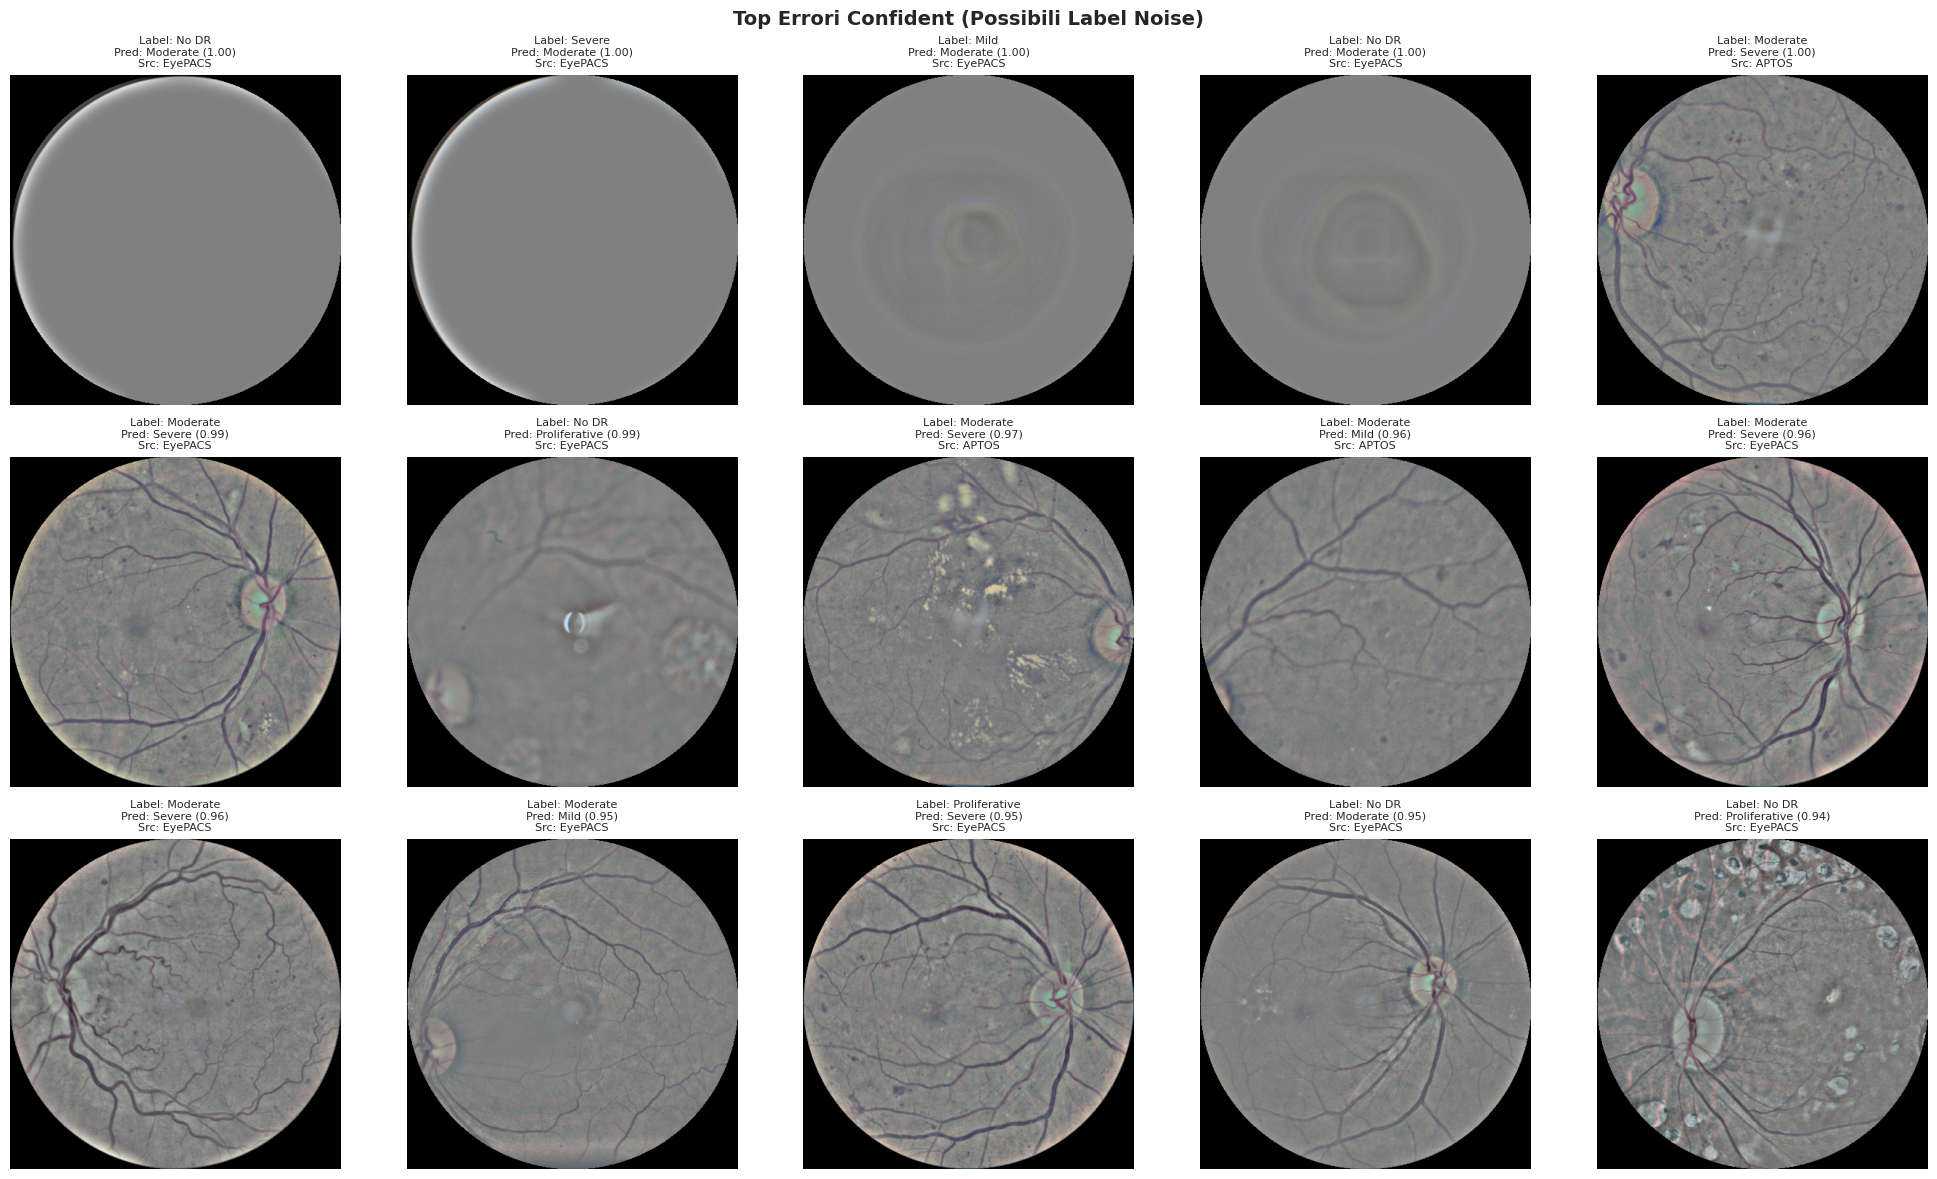

In [11]:
# Visualizza i top errori confident
n_show = min(15, len(train_errors_confident))
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for idx, (_, row) in enumerate(train_errors_confident.head(n_show).iterrows()):
    ax = axes[idx // 5, idx % 5]
    img_path = row['preprocessed_path']
    if not Path(img_path).is_absolute():
        img_path = PROJECT_ROOT / img_path
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Label: {CLASS_NAMES[row['diagnosis']]}\n"
                 f"Pred: {CLASS_NAMES[row['pred']]} ({row['confidence']:.2f})\n"
                 f"Src: {row['source']}", fontsize=8)
    ax.axis('off')

plt.suptitle('Top Errori Confident (Possibili Label Noise)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'top_confident_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analisi Errori per Source Dataset

In [12]:
# Metriche separate per source
print("Performance per Source Dataset")
print("=" * 70)

for source in ['APTOS', 'EyePACS']:
    src_data = train_results[train_results['source'] == source]
    acc = accuracy_score(src_data['diagnosis'], src_data['pred'])
    kappa = cohen_kappa_score(src_data['diagnosis'], src_data['pred'], weights='quadratic')
    f1 = f1_score(src_data['diagnosis'], src_data['pred'], average='macro')
    
    print(f"\n{source} ({len(src_data):,} campioni):")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"  Kappa: {kappa:.4f}")
    print(f"  F1 Macro: {f1:.4f}")
    
    # Per-class accuracy
    print(f"  Per-class accuracy:")
    for cls in range(NUM_CLASSES):
        cls_data = src_data[src_data['diagnosis'] == cls]
        if len(cls_data) > 0:
            cls_acc = (cls_data['pred'] == cls_data['diagnosis']).mean()
            print(f"    {CLASS_NAMES[cls]}: {cls_acc*100:.1f}% ({len(cls_data)} campioni)")
        else:
            print(f"    {CLASS_NAMES[cls]}: N/A (0 campioni)")

Performance per Source Dataset

APTOS (2,815 campioni):
  Accuracy: 92.29%
  Kappa: 0.9675
  F1 Macro: 0.8826
  Per-class accuracy:
    No DR: 97.3% (1377 campioni)
    Mild: 96.1% (284 campioni)
    Moderate: 82.2% (776 campioni)
    Severe: 91.2% (159 campioni)
    Proliferative: 92.2% (219 campioni)

EyePACS (29,428 campioni):
  Accuracy: 90.58%
  Kappa: 0.9036
  F1 Macro: 0.8426
  Per-class accuracy:
    No DR: 94.1% (21678 campioni)
    Mild: 76.2% (2059 campioni)
    Moderate: 78.7% (4411 campioni)
    Severe: 93.5% (719 campioni)
    Proliferative: 95.9% (561 campioni)


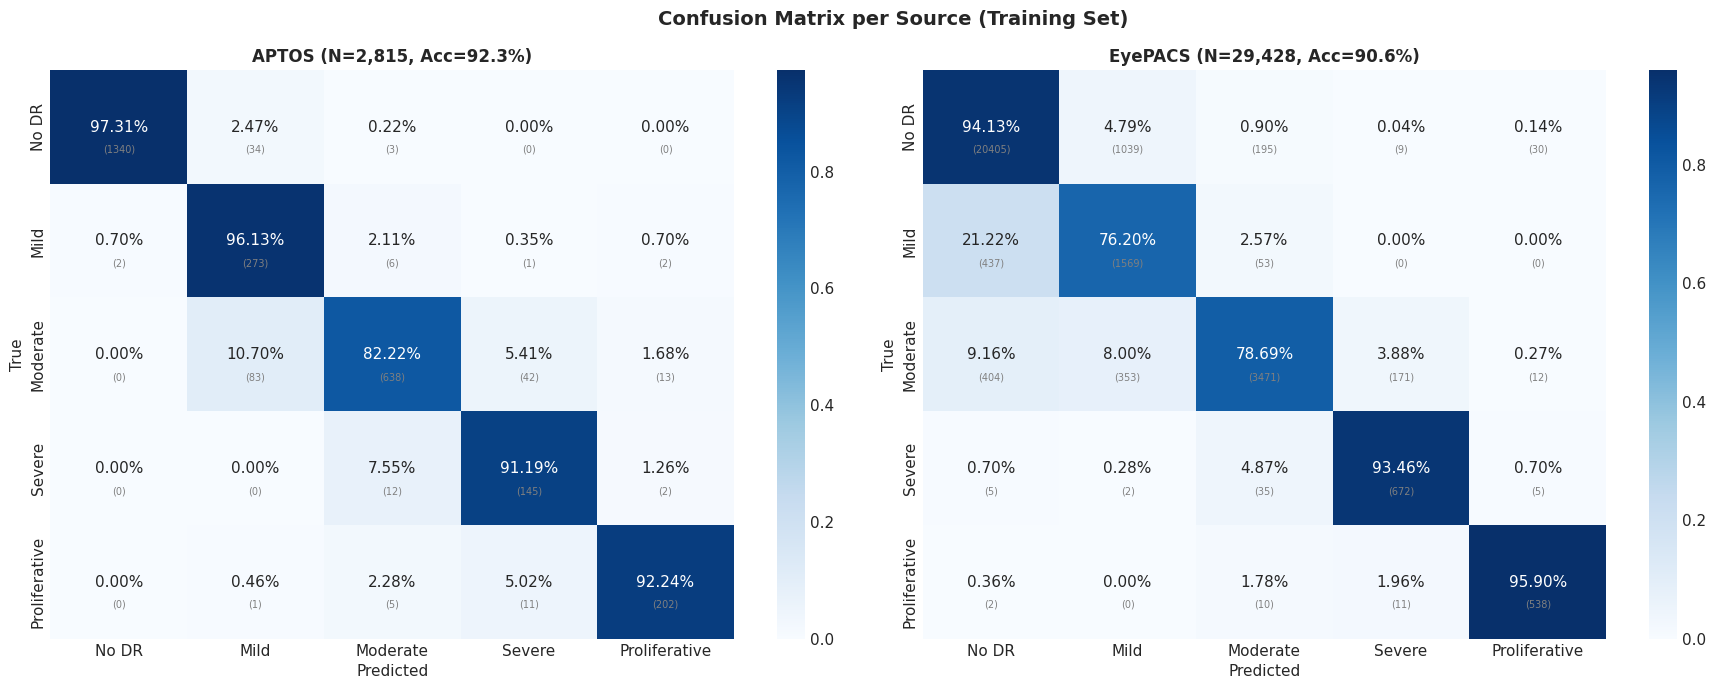

In [13]:
# Confusion matrix per source
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, source in enumerate(['APTOS', 'EyePACS']):
    src_data = train_results[train_results['source'] == source]
    cm = confusion_matrix(src_data['diagnosis'], src_data['pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
                yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
                ax=axes[idx])
    
    # Conteggi assoluti
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j + 0.5, i + 0.7, f'({cm[i, j]})',
                          ha='center', va='center', fontsize=7, color='gray')
    
    acc = accuracy_score(src_data['diagnosis'], src_data['pred'])
    axes[idx].set_title(f'{source} (N={len(src_data):,}, Acc={acc*100:.1f}%)',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.suptitle('Confusion Matrix per Source (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'confusion_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Matrice di Confusione Dettagliata e Pattern di Errore

In [14]:
# Analisi errori off-by-one vs errori gravi (validation set)
val_errors = val_results[val_results['correct'] == 0].copy()
val_errors['error_distance'] = abs(val_errors['diagnosis'] - val_errors['pred'])

print("Analisi Pattern di Errore (Validation Set)")
print("=" * 60)
print(f"Totale errori: {len(val_errors)} / {len(val_results)} ({len(val_errors)/len(val_results)*100:.1f}%)")

# Distribuzione distanza errore
print(f"\nDistribuzione distanza errore:")
for dist in sorted(val_errors['error_distance'].unique()):
    count = (val_errors['error_distance'] == dist).sum()
    pct = count / len(val_errors) * 100
    print(f"  Distanza {dist}: {count} errori ({pct:.1f}%)")

# Transizioni di errore piu comuni
print(f"\nTop 10 transizioni di errore:")
error_transitions = val_errors.groupby(['diagnosis', 'pred']).size().sort_values(ascending=False)
for (true_cls, pred_cls), count in error_transitions.head(10).items():
    total_true = len(val_results[val_results['diagnosis'] == true_cls])
    print(f"  {CLASS_NAMES[true_cls]:15s} -> {CLASS_NAMES[pred_cls]:15s}: {count:4d} "
          f"({count/total_true*100:.1f}% della classe)")

Analisi Pattern di Errore (Validation Set)
Totale errori: 1027 / 5690 (18.0%)

Distribuzione distanza errore:
  Distanza 1: 740 errori (72.1%)
  Distanza 2: 266 errori (25.9%)
  Distanza 3: 12 errori (1.2%)
  Distanza 4: 9 errori (0.9%)

Top 10 transizioni di errore:
  No DR           -> Mild           :  220 (5.4% della classe)
  Mild            -> No DR          :  159 (38.5% della classe)
  Moderate        -> No DR          :  146 (16.0% della classe)
  Moderate        -> Mild           :  137 (15.0% della classe)
  Moderate        -> Severe         :   87 (9.5% della classe)
  No DR           -> Moderate       :   64 (1.6% della classe)
  Severe          -> Moderate       :   57 (36.8% della classe)
  Mild            -> Moderate       :   53 (12.8% della classe)
  Proliferative   -> Moderate       :   33 (23.9% della classe)
  Proliferative   -> Severe         :   21 (15.2% della classe)


In [15]:
# Focus su Mild: dove vengono classificati?
print("\nFocus classe MILD")
print("=" * 60)

for split_name, results in [('Validation', val_results), ('Test', test_results)]:
    mild_data = results[results['diagnosis'] == 1]
    print(f"\n{split_name} ({len(mild_data)} campioni Mild):")
    pred_dist = mild_data['pred'].value_counts().sort_index()
    for pred_cls, count in pred_dist.items():
        pct = count / len(mild_data) * 100
        print(f"  Predetto come {CLASS_NAMES[pred_cls]:15s}: {count:4d} ({pct:.1f}%)")
    
    # Confidence media per predizione corretta vs errata
    mild_correct = mild_data[mild_data['correct'] == 1]
    mild_wrong = mild_data[mild_data['correct'] == 0]
    print(f"  Confidence media corretti: {mild_correct['confidence'].mean():.3f} (N={len(mild_correct)})")
    print(f"  Confidence media errati:   {mild_wrong['confidence'].mean():.3f} (N={len(mild_wrong)})")


Focus classe MILD

Validation (413 campioni Mild):
  Predetto come No DR          :  159 (38.5%)
  Predetto come Mild           :  197 (47.7%)
  Predetto come Moderate       :   53 (12.8%)
  Predetto come Severe         :    2 (0.5%)
  Predetto come Proliferative  :    2 (0.5%)
  Confidence media corretti: 0.699 (N=197)
  Confidence media errati:   0.665 (N=216)

Test (270 campioni Mild):
  Predetto come No DR          :  122 (45.2%)
  Predetto come Mild           :  105 (38.9%)
  Predetto come Moderate       :   43 (15.9%)
  Confidence media corretti: 0.643 (N=105)
  Confidence media errati:   0.629 (N=165)


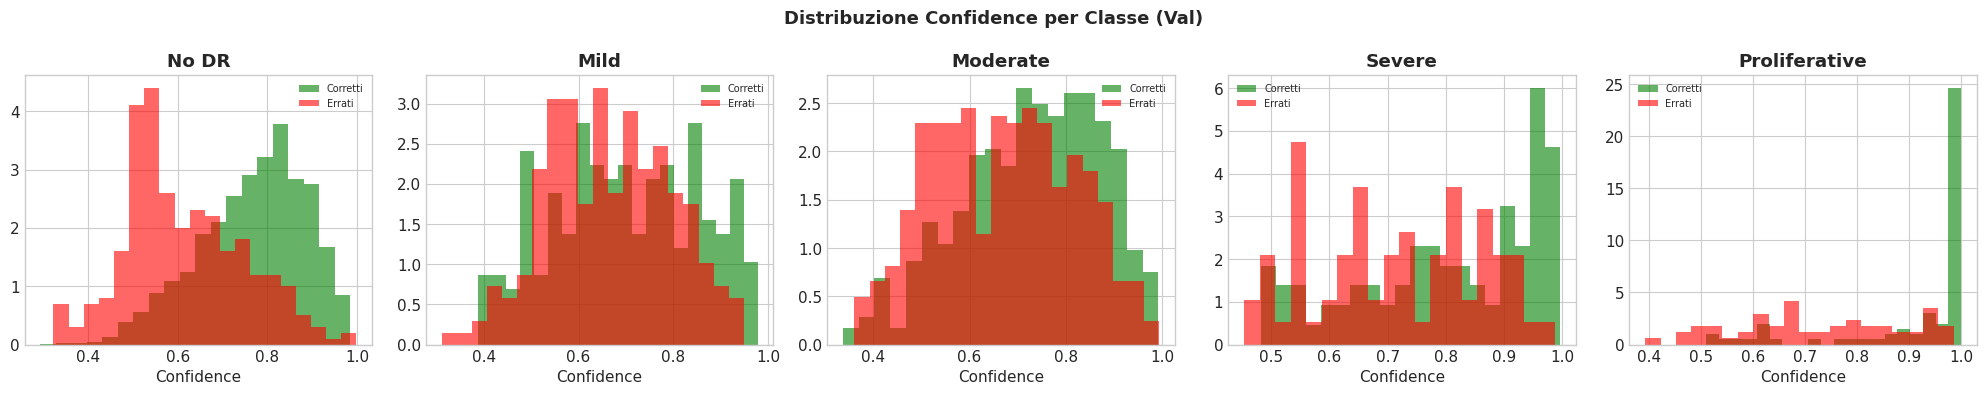

In [16]:
# Distribuzione confidence per classe
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for cls in range(NUM_CLASSES):
    cls_data = val_results[val_results['diagnosis'] == cls]
    correct = cls_data[cls_data['correct'] == 1]['confidence']
    wrong = cls_data[cls_data['correct'] == 0]['confidence']
    
    axes[cls].hist(correct, bins=20, alpha=0.6, label='Corretti', color='green', density=True)
    if len(wrong) > 0:
        axes[cls].hist(wrong, bins=20, alpha=0.6, label='Errati', color='red', density=True)
    axes[cls].set_title(CLASS_NAMES[cls], fontweight='bold')
    axes[cls].set_xlabel('Confidence')
    axes[cls].legend(fontsize=7)

plt.suptitle('Distribuzione Confidence per Classe (Val)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Test APTOS-only vs Merged

In [17]:
# Addestra un modello solo su APTOS per confronto
from torch.cuda.amp import GradScaler

# Split APTOS: usa la colonna split originale
aptos_train = aptos_df[aptos_df['split'] == 'train'].copy()
aptos_val = aptos_df[aptos_df['split'] == 'valid'].copy()

print(f"APTOS-only split:")
print(f"  Train: {len(aptos_train):,}")
print(f"  Valid: {len(aptos_val):,}")

print(f"\nDistribuzione classi APTOS train:")
for cls in range(NUM_CLASSES):
    count = (aptos_train['diagnosis'] == cls).sum()
    print(f"  {CLASS_NAMES[cls]}: {count} ({count/len(aptos_train)*100:.1f}%)")

APTOS-only split:
  Train: 2,930
  Valid: 366

Distribuzione classi APTOS train:
  No DR: 1434 (48.9%)
  Mild: 300 (10.2%)
  Moderate: 808 (27.6%)
  Severe: 154 (5.3%)
  Proliferative: 234 (8.0%)


In [18]:
# Training augmentation
aug_cfg = config['augmentation']
train_transforms_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=aug_cfg['rotation_limit'], border_mode=cv2.BORDER_CONSTANT, value=0,
             p=aug_cfg['prob_geometric']),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=aug_cfg['brightness_limit'],
                                   contrast_limit=aug_cfg['contrast_limit'], p=1.0),
        A.HueSaturationValue(hue_shift_limit=aug_cfg['hue_shift_limit'],
                             sat_shift_limit=int(aug_cfg['saturation_limit'] * 100),
                             val_shift_limit=int(aug_cfg['brightness_limit'] * 100), p=1.0),
    ], p=aug_cfg['prob_color']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])


def compute_class_weights(labels):
    """Calcola pesi per bilanciare la loss."""
    class_counts = np.bincount(labels)
    n_samples = len(labels)
    n_classes = len(class_counts)
    return torch.FloatTensor(n_samples / (n_classes * class_counts))

In [19]:
# Focal Loss (stessa definizione usata nei notebook 04)
class FocalLoss(nn.Module):
    """Focal Loss con class weights e label smoothing."""
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        num_classes = inputs.size(1)
        if self.label_smoothing > 0:
            with torch.no_grad():
                targets_smooth = torch.zeros_like(inputs)
                targets_smooth.fill_(self.label_smoothing / (num_classes - 1))
                targets_smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            targets_smooth = F.one_hot(targets, num_classes).float()
        p = F.softmax(inputs, dim=1)
        p_t = (p * targets_smooth).sum(dim=1)
        focal_weight = (1 - p_t) ** self.gamma
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        focal_loss = focal_weight * ce_loss
        if self.alpha is not None:
            focal_loss = self.alpha[targets] * focal_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

In [20]:
# Training APTOS-only
aptos_model = timm.create_model(
    MODEL_CONFIG['architecture'], pretrained=True,
    num_classes=NUM_CLASSES, drop_rate=MODEL_CONFIG['dropout_rate']
).to(DEVICE)

# Dataset e DataLoader
aptos_train_ds = DRDataset(aptos_train, transform=train_transforms_aug, project_root=PROJECT_ROOT)
aptos_val_ds = DRDataset(aptos_val, transform=val_transforms, project_root=PROJECT_ROOT)

aptos_train_loader = DataLoader(aptos_train_ds, batch_size=16, shuffle=True,
                                 num_workers=4, pin_memory=True, drop_last=True)
aptos_val_loader = DataLoader(aptos_val_ds, batch_size=16, shuffle=False,
                               num_workers=4, pin_memory=True)

# Class weights e loss
aptos_weights = compute_class_weights(aptos_train['diagnosis'].values).to(DEVICE)
aptos_criterion = FocalLoss(gamma=2.0, alpha=aptos_weights, label_smoothing=0.1)

# Optimizer e scheduler (stessa config di 04d)
aptos_optimizer = torch.optim.AdamW(aptos_model.parameters(), lr=1e-5, weight_decay=1e-5)
aptos_scaler = GradScaler()

# Training rapido (30 epoche con early stopping)
APTOS_EPOCHS = 30
best_aptos_kappa = 0.0
patience_counter = 0
aptos_history = {'val_acc': [], 'val_kappa': []}

print(f"Training APTOS-only ({len(aptos_train):,} campioni)")
print("=" * 50)

for epoch in tqdm(range(APTOS_EPOCHS), desc='APTOS-only'):
    # Training
    aptos_model.train()
    for images, labels in aptos_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        aptos_optimizer.zero_grad()
        with autocast():
            outputs = aptos_model(images)
            loss = aptos_criterion(outputs, labels)
        aptos_scaler.scale(loss).backward()
        aptos_scaler.unscale_(aptos_optimizer)
        torch.nn.utils.clip_grad_norm_(aptos_model.parameters(), 1.0)
        aptos_scaler.step(aptos_optimizer)
        aptos_scaler.update()
    
    # Validation
    aptos_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in aptos_val_loader:
            images = images.to(DEVICE)
            preds = aptos_model(images).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    val_acc = accuracy_score(all_labels, all_preds)
    val_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    aptos_history['val_acc'].append(val_acc)
    aptos_history['val_kappa'].append(val_kappa)
    
    if (epoch + 1) % 5 == 0:
        tqdm.write(f"Epoch {epoch+1}: Val Acc={val_acc*100:.1f}%, Kappa={val_kappa:.4f}")
    
    # Early stopping
    if val_kappa > best_aptos_kappa + 0.001:
        best_aptos_kappa = val_kappa
        patience_counter = 0
        # Salva best model in memoria
        best_aptos_state = {k: v.cpu().clone() for k, v in aptos_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= 7:
            tqdm.write(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nMiglior APTOS-only Kappa: {best_aptos_kappa:.4f}")

Training APTOS-only (2,930 campioni)


APTOS-only:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 5: Val Acc=77.6%, Kappa=0.8332
Epoch 10: Val Acc=81.4%, Kappa=0.8816
Epoch 15: Val Acc=78.4%, Kappa=0.8658
Epoch 20: Val Acc=84.7%, Kappa=0.8935
Epoch 25: Val Acc=82.8%, Kappa=0.8976
Epoch 30: Val Acc=82.2%, Kappa=0.8816

Miglior APTOS-only Kappa: 0.9064


In [21]:
# Valutazione APTOS-only su val e test
aptos_model.load_state_dict(best_aptos_state)
aptos_model = aptos_model.to(DEVICE)

print("Valutazione modello APTOS-only:")
print("=" * 60)

print("\nAPTOS Validation (366 campioni):")
aptos_val_results = run_inference(aptos_model, aptos_val, DEVICE)

# Test su Messidor-2 (cross-dataset)
print("\nMessidor-2 Test (1,744 campioni):")
aptos_test_results = run_inference(aptos_model, test_df, DEVICE)

# Confronto diretto
print("\n" + "=" * 60)
print("CONFRONTO: APTOS-only vs Merged (04d)")
print("=" * 60)

# Val su APTOS-only val
aptos_val_acc = accuracy_score(aptos_val_results['diagnosis'], aptos_val_results['pred'])
aptos_val_kappa = cohen_kappa_score(aptos_val_results['diagnosis'], aptos_val_results['pred'], weights='quadratic')

# Test su Messidor-2
aptos_test_acc = accuracy_score(aptos_test_results['diagnosis'], aptos_test_results['pred'])
aptos_test_kappa = cohen_kappa_score(aptos_test_results['diagnosis'], aptos_test_results['pred'], weights='quadratic')

print(f"{'Metrica':<25} {'APTOS-only':>15} {'Merged (04d)':>15}")
print("-" * 55)
print(f"{'APTOS Val Acc':<25} {aptos_val_acc*100:>14.2f}% {'N/A':>15}")
print(f"{'APTOS Val Kappa':<25} {aptos_val_kappa:>15.4f} {'N/A':>15}")
print(f"{'Messidor-2 Test Acc':<25} {aptos_test_acc*100:>14.2f}% {73.68:>14.2f}%")
print(f"{'Messidor-2 Test Kappa':<25} {aptos_test_kappa:>15.4f} {0.8294:>15.4f}")

# F1 per classe sul test
aptos_f1 = f1_score(aptos_test_results['diagnosis'], aptos_test_results['pred'], average=None)
merged_f1 = [0.8497, 0.3770, 0.6921, 0.6424, 0.6885]  # Da 04d

print(f"\nF1 per classe (Messidor-2):")
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:<15} {aptos_f1[i]:>10.4f} {merged_f1[i]:>15.4f}")

Valutazione modello APTOS-only:

APTOS Validation (366 campioni):


Inferenza:   0%|          | 0/23 [00:00<?, ?it/s]

Accuracy: 84.97%, Kappa: 0.9064

Messidor-2 Test (1,744 campioni):


Inferenza:   0%|          | 0/109 [00:00<?, ?it/s]

Accuracy: 68.69%, Kappa: 0.6481

CONFRONTO: APTOS-only vs Merged (04d)
Metrica                        APTOS-only    Merged (04d)
-------------------------------------------------------
APTOS Val Acc                      84.97%             N/A
APTOS Val Kappa                    0.9064             N/A
Messidor-2 Test Acc                68.69%          73.68%
Messidor-2 Test Kappa              0.6481          0.8294

F1 per classe (Messidor-2):
  No DR               0.8214          0.8497
  Mild                0.0594          0.3770
  Moderate            0.5354          0.6921
  Severe              0.3619          0.6424
  Proliferative       0.5479          0.6885


## 6. Stima Label Noise con Confident Learning

In [22]:
# Matrice di transizione stimata dal training set
# Q[i][j] = P(label=j | true=i) - stima quante label sono sbagliate
def estimate_noise_matrix(results_df, num_classes):
    """
    Stima la matrice di confusione delle label usando le predizioni del modello.
    Assume che il modello sia ragionevolmente buono e che gli errori sistematici
    indichino label noise.
    """
    # Usa solo campioni con alta confidence come "pseudo ground truth"
    confident = results_df[results_df['confidence'] > 0.7].copy()
    
    # Matrice: label originale vs predizione del modello
    cm = confusion_matrix(confident['diagnosis'], confident['pred'],
                          labels=range(num_classes))
    
    # Normalizza per riga
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    noise_matrix = cm.astype(float) / row_sums
    
    return noise_matrix, confident


noise_matrix, confident_samples = estimate_noise_matrix(train_results, NUM_CLASSES)

print("Matrice di Transizione Stimata (Label -> Predizione Modello)")
print("Campioni confident (>0.7): {:,}".format(len(confident_samples)))
print("=" * 70)
print(f"{'':>15}", end='')
for j in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[j]:>12}", end='')
print()

for i in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[i]:>15}", end='')
    for j in range(NUM_CLASSES):
        val = noise_matrix[i, j]
        marker = ' *' if i != j and val > 0.10 else ''
        print(f"{val:>10.1%}{marker}", end='')
    print()

print("\n* = transizione > 10% (possibile label noise sistematico)")

Matrice di Transizione Stimata (Label -> Predizione Modello)
Campioni confident (>0.7): 21,847
                      No DR        Mild    Moderate      SevereProliferative
          No DR     98.7%      1.1%      0.1%      0.0%      0.1%
           Mild      6.2%     93.2%      0.5%      0.0%      0.1%
       Moderate      3.1%      3.6%     90.7%      2.4%      0.3%
         Severe      0.0%      0.0%      0.5%     99.1%      0.4%
  Proliferative      0.0%      0.1%      0.4%      1.1%     98.3%

* = transizione > 10% (possibile label noise sistematico)


In [23]:
# Identifica campioni con probabile label errata
# Criterio: il modello predice una classe diversa con confidence > 0.9
def identify_noisy_labels(results_df, confidence_threshold=0.9):
    """Identifica campioni dove il modello e molto sicuro che la label sia sbagliata."""
    noisy = results_df[
        (results_df['correct'] == 0) &
        (results_df['confidence'] > confidence_threshold)
    ].copy()
    return noisy


noisy_labels = identify_noisy_labels(train_results, confidence_threshold=0.9)

print(f"Campioni con probabile label errata (conf > 0.9):")
print(f"  Totale: {len(noisy_labels):,} / {len(train_results):,} "
      f"({len(noisy_labels)/len(train_results)*100:.2f}%)")

print(f"\nPer source:")
for source in noisy_labels['source'].unique():
    src_noisy = noisy_labels[noisy_labels['source'] == source]
    src_total = len(train_results[train_results['source'] == source])
    print(f"  {source}: {len(src_noisy):,} ({len(src_noisy)/src_total*100:.2f}%)")

print(f"\nPer classe (label originale):")
for cls in range(NUM_CLASSES):
    cls_noisy = noisy_labels[noisy_labels['diagnosis'] == cls]
    cls_total = len(train_results[train_results['diagnosis'] == cls])
    if cls_total > 0:
        print(f"  {CLASS_NAMES[cls]}: {len(cls_noisy):,} ({len(cls_noisy)/cls_total*100:.2f}%)")

print(f"\nTransizioni piu comuni (label -> predizione modello):")
transitions = noisy_labels.groupby(['diagnosis', 'pred']).size().sort_values(ascending=False)
for (true_cls, pred_cls), count in transitions.head(10).items():
    print(f"  {CLASS_NAMES[true_cls]:15s} -> {CLASS_NAMES[pred_cls]:15s}: {count}")

Campioni con probabile label errata (conf > 0.9):
  Totale: 33 / 32,243 (0.10%)

Per source:
  EyePACS: 27 (0.09%)
  APTOS: 6 (0.21%)

Per classe (label originale):
  No DR: 13 (0.06%)
  Mild: 1 (0.04%)
  Moderate: 17 (0.33%)
  Severe: 1 (0.11%)
  Proliferative: 1 (0.13%)

Transizioni piu comuni (label -> predizione modello):
  Moderate        -> Severe         : 10
  No DR           -> Moderate       : 6
  Moderate        -> Mild           : 5
  No DR           -> Mild           : 4
  No DR           -> Proliferative  : 3
  Mild            -> Moderate       : 1
  Moderate        -> No DR          : 1
  Moderate        -> Proliferative  : 1
  Severe          -> Moderate       : 1
  Proliferative   -> Severe         : 1


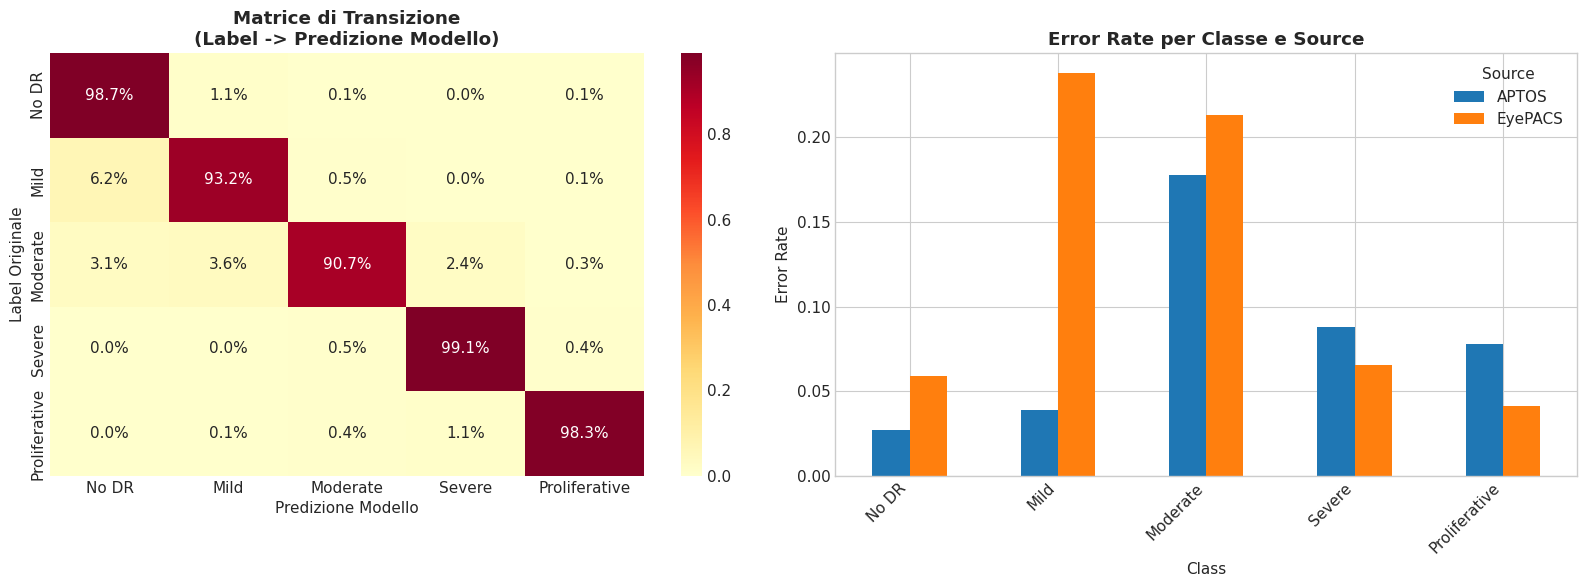

In [24]:
# Visualizzazione matrice di noise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice di transizione
sns.heatmap(noise_matrix, annot=True, fmt='.1%', cmap='YlOrRd',
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            ax=axes[0])
axes[0].set_title('Matrice di Transizione\n(Label -> Predizione Modello)', fontweight='bold')
axes[0].set_xlabel('Predizione Modello')
axes[0].set_ylabel('Label Originale')

# Noise rate per classe e source
noise_data = []
for source in ['APTOS', 'EyePACS']:
    for cls in range(NUM_CLASSES):
        src_cls = train_results[(train_results['source'] == source) & 
                                (train_results['diagnosis'] == cls)]
        if len(src_cls) > 0:
            error_rate = 1 - src_cls['correct'].mean()
            noise_data.append({'Source': source, 'Class': CLASS_NAMES[cls], 'Error Rate': error_rate})

noise_df = pd.DataFrame(noise_data)
noise_pivot = noise_df.pivot(index='Class', columns='Source', values='Error Rate')
noise_pivot = noise_pivot.reindex([CLASS_NAMES[i] for i in range(NUM_CLASSES)])
noise_pivot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Error Rate per Classe e Source', fontweight='bold')
axes[1].set_ylabel('Error Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(title='Source')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusioni e Raccomandazioni

In [25]:
# Riepilogo analisi
print("=" * 70)
print("RIEPILOGO ANALISI")
print("=" * 70)

# 1. Label noise
total_noisy = len(noisy_labels)
print(f"\n1. LABEL NOISE STIMATO")
print(f"   Campioni con probabile label errata (conf>0.9): {total_noisy:,}")
print(f"   Percentuale sul training: {total_noisy/len(train_results)*100:.2f}%")

for source in ['APTOS', 'EyePACS']:
    src_noisy = noisy_labels[noisy_labels['source'] == source]
    src_total = len(train_results[train_results['source'] == source])
    print(f"   {source}: {len(src_noisy)/src_total*100:.2f}% noise rate")

# 2. APTOS-only vs Merged
print(f"\n2. APTOS-ONLY vs MERGED")
print(f"   APTOS-only Val Kappa: {best_aptos_kappa:.4f}")
print(f"   Merged (04d) Val Kappa: 0.8174")
print(f"   APTOS-only Test Kappa: {aptos_test_kappa:.4f}")
print(f"   Merged (04d) Test Kappa: 0.8294")

# 3. Pattern errori
print(f"\n3. PATTERN ERRORI")
val_errors = val_results[val_results['correct'] == 0]
off_by_one = val_errors[abs(val_errors['diagnosis'] - val_errors['pred']) == 1]
print(f"   Errori off-by-one: {len(off_by_one)}/{len(val_errors)} "
      f"({len(off_by_one)/len(val_errors)*100:.1f}%)")

# 4. Raccomandazioni
print(f"\n4. RACCOMANDAZIONI")
print(f"   - Da valutare se filtrare label noise e riaddestrare")
print(f"   - Da valutare impatto APTOS-only vs merged sui risultati")
print(f"   - Mild resta la classe piu problematica in tutti gli scenari")

# Salva report
report = {
    'noise_analysis': {
        'total_noisy_samples': int(total_noisy),
        'noise_rate': float(total_noisy / len(train_results)),
        'noise_matrix': noise_matrix.tolist()
    },
    'aptos_only': {
        'val_kappa': float(best_aptos_kappa),
        'test_kappa': float(aptos_test_kappa),
        'test_acc': float(aptos_test_acc)
    },
    'merged_04d': {
        'val_kappa': 0.8174,
        'test_kappa': 0.8294,
        'test_acc': 0.7368
    }
}

with open(ANALYSIS_DIR / 'analysis_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f"\nReport salvato: {ANALYSIS_DIR / 'analysis_report.json'}")

RIEPILOGO ANALISI

1. LABEL NOISE STIMATO
   Campioni con probabile label errata (conf>0.9): 33
   Percentuale sul training: 0.10%
   APTOS: 0.21% noise rate
   EyePACS: 0.09% noise rate

2. APTOS-ONLY vs MERGED
   APTOS-only Val Kappa: 0.9064
   Merged (04d) Val Kappa: 0.8174
   APTOS-only Test Kappa: 0.6481
   Merged (04d) Test Kappa: 0.8294

3. PATTERN ERRORI
   Errori off-by-one: 740/1027 (72.1%)

4. RACCOMANDAZIONI
   - Da valutare se filtrare label noise e riaddestrare
   - Da valutare impatto APTOS-only vs merged sui risultati
   - Mild resta la classe piu problematica in tutti gli scenari

Report salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/error_analysis/analysis_report.json
